# Kalman Test Migration Notebook
This notebook migrates the `Kalman_test.py` flow into executable test-oriented cells.

## 1. Set Up Notebook Environment
Set reproducibility, paths, and display defaults.

In [ ]:
import os
import random
from pathlib import Path

import numpy as np

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

np.set_printoptions(precision=4, suppress=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Seed: {SEED}")

Project root: /home/berko/Documents/Python Codes/BDRS
Seed: 42


## 2. Import Kalman Filter Dependencies
Import Kalman implementation, CSV loader, plotting, and helper assertion utilities.

In [350]:
from math import cos, sin
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from IPython.display import Image, display

from Kalman_class import KalmanFilter
from csv_loader import CSVDataLoader


def assert_close(a, b, atol=1e-6, rtol=1e-6, msg=""):
    if not np.allclose(a, b, atol=atol, rtol=rtol):
        raise AssertionError(msg or f"Arrays are not close.\nA={a}\nB={b}")

## 3. Load or Recreate Test Fixtures
Define deterministic initial state, model matrices, and measurement/control fixtures from CSV.

In [ ]:
L = 0.1 # Distance between the two wheels
DT = 0.1 # Time step

# Failure scenario selector (0 = nominal, 1..10 = generated failure files)
FAILURE_CASE = 8

FAILURE_DESCRIPTIONS = {
    0: "Nominal sensors (baseline sensor_measurements.csv)",
    1: "pos_x fault: large drift/noise",
    2: "pos_y fault: intermittent outlier spikes",
    3: "pos_z fault: elevated measurement noise",
    4: "velocity fault: positive bias",
    5: "yaw fault: positive bias",
    6: "angular_velocity fault: spike bursts/outliers",
    7: "pitch fault: elevated jitter/noise",
    8: "mixed fault: pos_x and velocity disturbance",
    9: "mixed fault: severe angular_velocity spikes with yaw disturbance",
    10: "mixed fault: pos_x/pos_y disturbance with secondary velocity/angular_velocity effects",
}


def resolve_measurement_file(case_id: int) -> str:
    if case_id == 0:
        return "sensor_measurements.csv"
    if 1 <= case_id <= 10:
        return f"sensor_measurements_failure_{case_id:02d}.csv"
    raise ValueError("FAILURE_CASE must be in range [0, 10]")


measurement_file = resolve_measurement_file(FAILURE_CASE)
failure_description = FAILURE_DESCRIPTIONS[FAILURE_CASE]

# Initial state components
initial_px = 0 # Initial x (global) position
initial_py = 0.0 # Initial y (global) position
initial_pz = 0.0 # Initial z (global) position
initial_velocity = 0 # Initial linear velocity
initial_angular_velocity = 0.0 # Initial angular velocity
initial_yaw = 0.0 # Initial yaw
initial_pitch = 0.0 # Initial pitch


def build_state_transition_matrix(yaw: float, pitch: float, dt_s: float) -> np.ndarray:
    return np.array([
        [1.0, 0.0, 0.0, cos(pitch) * cos(yaw) * dt_s, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, cos(pitch) * sin(yaw) * dt_s, 0.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, sin(pitch) * dt_s, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, dt_s, 1.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
    ])


A0 = build_state_transition_matrix(initial_yaw, initial_pitch, DT)
B = np.array([
    [0.0, 0.0],
    [0.0, 0.0],
    [0.0, 0.0],
    [0.5, 0.5],
    [-0.315 / L, 0.315 / L],
    [0.0, 0.0],
    [0.0, 0.0],
])
H = np.eye(7)

# State order for all vectors/matrices:
# 0=pos_x, 1=pos_y, 2=pos_z, 3=velocity, 4=angular_velocity, 5=yaw, 6=pitch

# Process noise variance per state (Q diagonal). Edit each entry by hand.
q_diag = np.array([
    0.06,  # 0 pos_x process variance
    0.06,  # 1 pos_y process variance
    0.06,  # 2 pos_z process variance
    0.01,  # 3 velocity process variance
    0.01,  # 4 angular_velocity process variance
    0.01,  # 5 yaw process variance
    0.01,  # 6 pitch process variance
])

# Measurement noise variance per state (R diagonal). Edit each entry by hand.
r_diag = np.array([
    0.5,   # 0 pos_x measurement variance
    0.5,   # 1 pos_y measurement variance
    0.5,   # 2 pos_z measurement variance
    0.1,   # 3 velocity measurement variance
    0.1,   # 4 angular_velocity measurement variance
    0.1,   # 5 yaw measurement variance
    0.1,   # 6 pitch measurement variance
])

Q = np.diag(q_diag)
R = np.diag(r_diag)

x0 = np.array([
    [initial_px],
    [initial_py],
    [initial_pz],
    [initial_velocity],
    [initial_angular_velocity],
    [initial_yaw],
    [initial_pitch],
], dtype=float)

loader = CSVDataLoader()
measurements = loader.load_measurements_7x1(
    measurement_file,
    columns=["pos_x", "pos_y", "pos_z", "velocity", "angular_velocity", "yaw", "pitch"],
)
control_inputs = loader.load_control_inputs_2x1("control_inputs.csv", left_column="u_left", right_column="u_right")

print(f"Failure case {FAILURE_CASE}: {failure_description}")
print(f"Measurement source: {measurement_file}")
print(len(measurements), len(control_inputs), measurements[0].shape, control_inputs[0].shape)

Failure case 8: mixed fault: pos_x and velocity disturbance
Measurement source: sensor_measurements_failure_08.csv
100 100 (7, 1) (2, 1)


## 4. Port Core Kalman Test Cases
Port script logic into notebook test cells with assertions for dimensions and finite outputs.

In [352]:
kf = KalmanFilter(A0.copy(), B.copy(), H.copy(), Q.copy(), R.copy())
kf.x = x0.copy()

assert len(measurements) == len(control_inputs), "CSV row counts must match"
assert measurements[0].shape == (7, 1), "Measurement vectors must be 7x1"
assert control_inputs[0].shape == (2, 1), "Control vectors must be 2x1"

z0 = measurements[0]
u0 = control_inputs[0]

kf.A = build_state_transition_matrix(float(kf.x[5, 0]), float(kf.x[6, 0]), DT)
kf.predict(u0)
kf.update(z0)

assert kf.x.shape == (7, 1), "State estimate must remain 7x1"
assert kf.P.shape == (7, 7), "Covariance must remain 7x7"
assert np.isfinite(kf.x).all(), "State contains non-finite values"
assert np.isfinite(kf.P).all(), "Covariance contains non-finite values"

print("Core test case passed for one predict/update step.")

Core test case passed for one predict/update step.


## 5. Add Parameter Sweep Test Cells
Sweep process/measurement noise and time-step scale factors to check numerical stability.

In [353]:
sweep_results = []

noise_scales = [0.5, 1.0, 2.0]
dt_scales = [0.5, 1.0, 1.5]

for q_scale in noise_scales:
    for r_scale in noise_scales:
        for dt_scale in dt_scales:
            dt_local = DT * dt_scale
            kf_sweep = KalmanFilter(A0.copy(), B.copy(), H.copy(), Q * q_scale, R * r_scale)
            kf_sweep.x = x0.copy()

            ok = True
            for z, u in zip(measurements[:20], control_inputs[:20]):
                kf_sweep.A = build_state_transition_matrix(
                    float(kf_sweep.x[5, 0]),
                    float(kf_sweep.x[6, 0]),
                    dt_local,
                )
                kf_sweep.predict(u)
                kf_sweep.update(z)
                if not (np.isfinite(kf_sweep.x).all() and np.isfinite(kf_sweep.P).all()):
                    ok = False
                    break

            sweep_results.append({
                "q_scale": q_scale,
                "r_scale": r_scale,
                "dt_scale": dt_scale,
                "passed": ok,
            })

sum(result["passed"] for result in sweep_results), len(sweep_results)

(27, 27)

## 6. Validate Numerical Tolerances
Compute absolute and relative consistency checks for state transitions and covariance symmetry.

In [354]:
kf_tol = KalmanFilter(A0.copy(), B.copy(), H.copy(), Q.copy(), R.copy())
kf_tol.x = x0.copy()

state_norm_errors = []
cov_symmetry_errors = []

for z, u in zip(measurements[:30], control_inputs[:30]):
    kf_tol.A = build_state_transition_matrix(
        float(kf_tol.x[5, 0]),
        float(kf_tol.x[6, 0]),
        DT,
    )
    x_prev = kf_tol.x.copy()
    kf_tol.predict(u)
    kf_tol.update(z)

    state_norm_errors.append(float(np.linalg.norm(kf_tol.x - x_prev)))
    cov_symmetry_errors.append(float(np.linalg.norm(kf_tol.P - kf_tol.P.T)))

state_norm_errors = np.array(state_norm_errors)
cov_symmetry_errors = np.array(cov_symmetry_errors)

print(f"max ||x_k - x_k-1||: {state_norm_errors.max():.6f}")
print(f"max ||P - P^T||: {cov_symmetry_errors.max():.6e}")

assert np.max(cov_symmetry_errors) < 1e-8, "Covariance symmetry tolerance failed"

max ||x_k - x_k-1||: 1.035360
max ||P - P^T||: 6.001115e-22


## 7. Visualize State and Covariance Evolution
Run full estimation, save a 3D trajectory GIF over time, and plot remaining states/covariance diagonals.

Saved GIF: /home/berko/Documents/Python Codes/BDRS/estimated_position_trajectory.gif


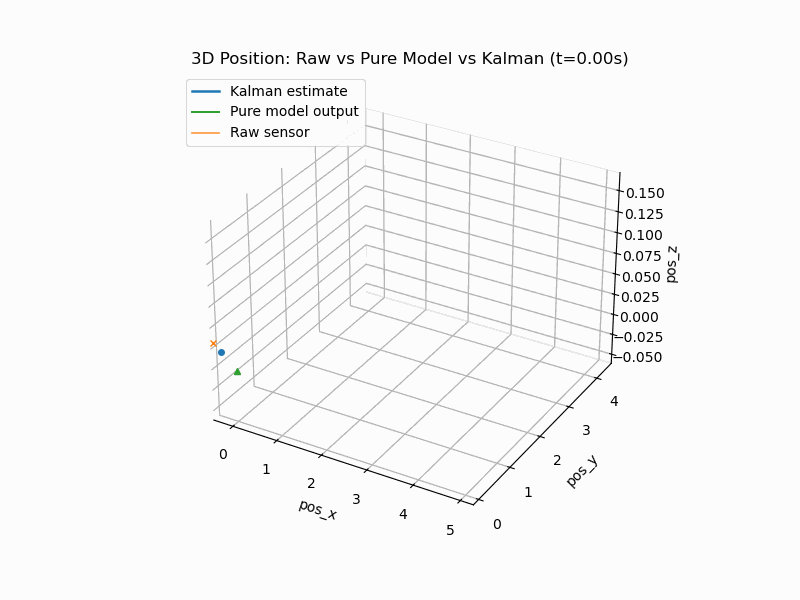

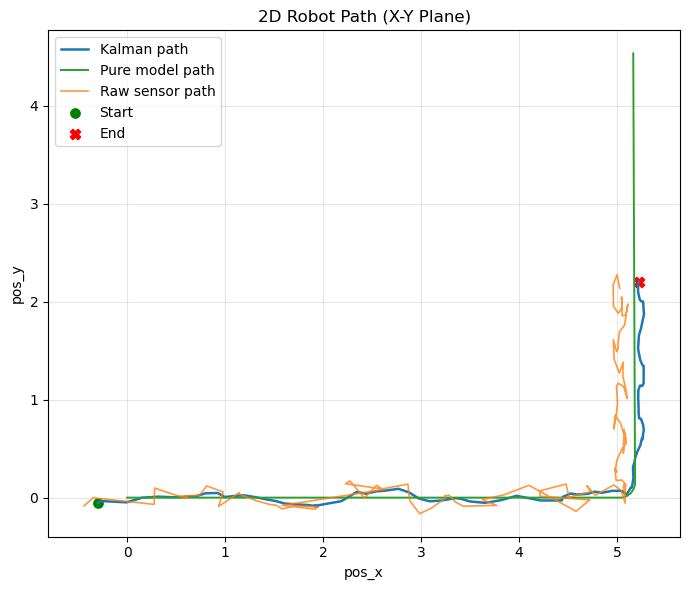

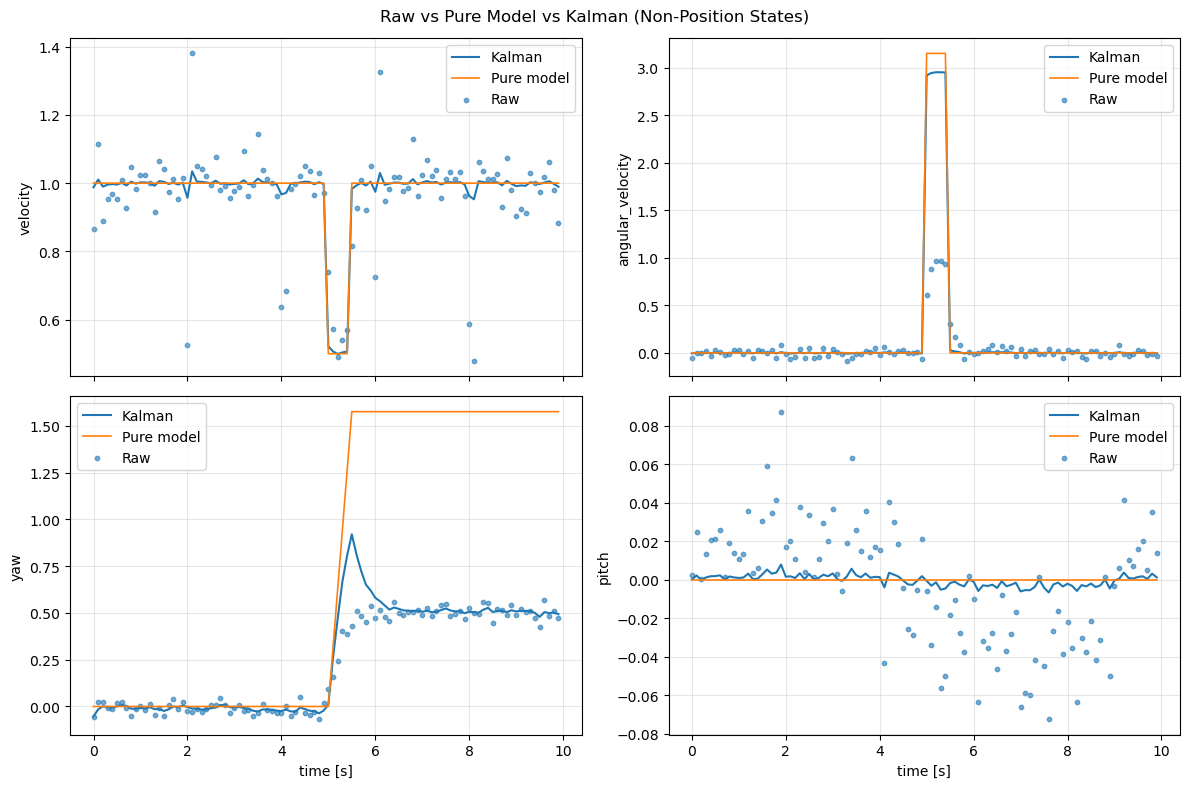

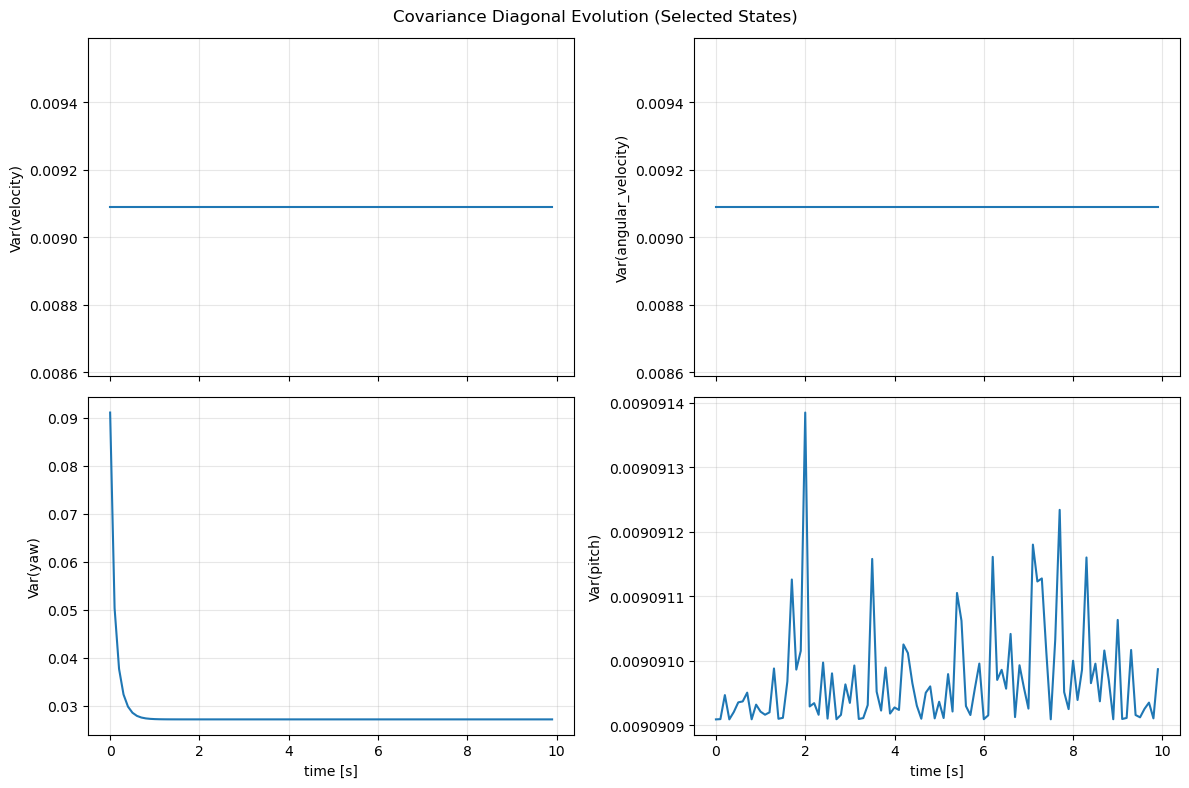

In [355]:
kf_vis = KalmanFilter(A0.copy(), B.copy(), H.copy(), Q.copy(), R.copy())
kf_vis.x = x0.copy()

times = []
estimated_history = []
pure_model_history = []
raw_history = []
P_diag_history = []

# Open-loop model state: propagated only by model and control input.
x_model = x0.copy()

for step, (z, u) in enumerate(zip(measurements, control_inputs)):
    # Pure model propagation (no measurement correction).
    A_model = build_state_transition_matrix(
        float(x_model[5, 0]),
        float(x_model[6, 0]),
        DT,
    )
    x_model = A_model @ x_model + B @ u
    pure_model_history.append(x_model.flatten())

    # Kalman filter propagation + correction.
    kf_vis.A = build_state_transition_matrix(
        float(kf_vis.x[5, 0]),
        float(kf_vis.x[6, 0]),
        DT,
    )
    kf_vis.predict(u)
    kf_vis.update(z)

    times.append(step * DT)
    estimated_history.append(kf_vis.x.flatten())
    raw_history.append(z.flatten())
    P_diag_history.append(np.diag(kf_vis.P))

estimated_history = np.array(estimated_history)
pure_model_history = np.array(pure_model_history)
raw_history = np.array(raw_history)
P_diag_history = np.array(P_diag_history)

# 3D animated trajectory comparison (raw vs pure model vs Kalman) -> GIF
fig_3d = plt.figure(figsize=(8, 6))
ax_3d = fig_3d.add_subplot(111, projection="3d")

x_est = estimated_history[:, 0]
y_est = estimated_history[:, 1]
z_est = estimated_history[:, 2]

x_model_vals = pure_model_history[:, 0]
y_model_vals = pure_model_history[:, 1]
z_model_vals = pure_model_history[:, 2]

x_raw = raw_history[:, 0]
y_raw = raw_history[:, 1]
z_raw = raw_history[:, 2]

line_est, = ax_3d.plot([], [], [], lw=1.8, color="tab:blue", label="Kalman estimate")
point_est, = ax_3d.plot([], [], [], marker="o", color="tab:blue", markersize=4)
line_model, = ax_3d.plot([], [], [], lw=1.4, color="tab:green", label="Pure model output")
point_model, = ax_3d.plot([], [], [], marker="^", color="tab:green", markersize=4)
line_raw, = ax_3d.plot([], [], [], lw=1.2, color="tab:orange", alpha=0.8, label="Raw sensor")
point_raw, = ax_3d.plot([], [], [], marker="x", color="tab:orange", markersize=5)

ax_3d.set_xlim(min(x_est.min(), x_model_vals.min(), x_raw.min()), max(x_est.max(), x_model_vals.max(), x_raw.max()))
ax_3d.set_ylim(min(y_est.min(), y_model_vals.min(), y_raw.min()), max(y_est.max(), y_model_vals.max(), y_raw.max()))
ax_3d.set_zlim(min(z_est.min(), z_model_vals.min(), z_raw.min()), max(z_est.max(), z_model_vals.max(), z_raw.max()))
ax_3d.set_xlabel("pos_x")
ax_3d.set_ylabel("pos_y")
ax_3d.set_zlabel("pos_z")
ax_3d.legend(loc="upper left")


def animate(frame_idx: int):
    line_est.set_data(x_est[: frame_idx + 1], y_est[: frame_idx + 1])
    line_est.set_3d_properties(z_est[: frame_idx + 1])
    point_est.set_data([x_est[frame_idx]], [y_est[frame_idx]])
    point_est.set_3d_properties([z_est[frame_idx]])

    line_model.set_data(x_model_vals[: frame_idx + 1], y_model_vals[: frame_idx + 1])
    line_model.set_3d_properties(z_model_vals[: frame_idx + 1])
    point_model.set_data([x_model_vals[frame_idx]], [y_model_vals[frame_idx]])
    point_model.set_3d_properties([z_model_vals[frame_idx]])

    line_raw.set_data(x_raw[: frame_idx + 1], y_raw[: frame_idx + 1])
    line_raw.set_3d_properties(z_raw[: frame_idx + 1])
    point_raw.set_data([x_raw[frame_idx]], [y_raw[frame_idx]])
    point_raw.set_3d_properties([z_raw[frame_idx]])

    ax_3d.set_title(f"3D Position: Raw vs Pure Model vs Kalman (t={times[frame_idx]:.2f}s)")
    return line_est, point_est, line_model, point_model, line_raw, point_raw


ani = FuncAnimation(fig_3d, animate, frames=len(times), interval=100, blit=False)
gif_path = Path("estimated_position_trajectory.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
plt.close(fig_3d)
print(f"Saved GIF: {gif_path.resolve()}")
display(Image(filename=str(gif_path)))

# Top-down 2D trajectory path (x-y)
fig_xy, ax_xy = plt.subplots(figsize=(7, 6))
ax_xy.plot(x_est, y_est, color="tab:blue", lw=1.8, label="Kalman path")
ax_xy.plot(x_model_vals, y_model_vals, color="tab:green", lw=1.4, label="Pure model path")
ax_xy.plot(x_raw, y_raw, color="tab:orange", lw=1.2, alpha=0.8, label="Raw sensor path")
ax_xy.scatter(x_est[0], y_est[0], color="green", marker="o", s=45, label="Start")
ax_xy.scatter(x_est[-1], y_est[-1], color="red", marker="X", s=55, label="End")
ax_xy.set_xlabel("pos_x")
ax_xy.set_ylabel("pos_y")
ax_xy.set_title("2D Robot Path (X-Y Plane)")
ax_xy.grid(True, alpha=0.3)
ax_xy.axis("equal")
ax_xy.legend(loc="best")
fig_xy.tight_layout()

# Remaining states over time: raw vs pure model vs Kalman
fig_state, axes_state = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes_state = axes_state.flatten()
remaining_names = ["velocity", "angular_velocity", "yaw", "pitch"]
remaining_idx = [3, 4, 5, 6]
for ax, name, idx in zip(axes_state, remaining_names, remaining_idx):
    ax.plot(times, estimated_history[:, idx], lw=1.5, label="Kalman")
    ax.plot(times, pure_model_history[:, idx], lw=1.2, label="Pure model")
    ax.scatter(times, raw_history[:, idx], s=10, alpha=0.6, label="Raw")
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
axes_state[2].set_xlabel("time [s]")
axes_state[3].set_xlabel("time [s]")
fig_state.suptitle("Raw vs Pure Model vs Kalman (Non-Position States)")
fig_state.tight_layout()

# Covariance diagonal evolution (Kalman internal uncertainty)
fig_cov, axes_cov = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes_cov = axes_cov.flatten()
for ax, name, idx in zip(axes_cov, remaining_names, remaining_idx):
    ax.plot(times, P_diag_history[:, idx], lw=1.5)
    ax.set_ylabel(f"Var({name})")
    ax.grid(True, alpha=0.3)
axes_cov[2].set_xlabel("time [s]")
axes_cov[3].set_xlabel("time [s]")
fig_cov.suptitle("Covariance Diagonal Evolution (Selected States)")
fig_cov.tight_layout()

plt.show()

## 8. Summarize Pass/Fail Results in Notebook
Collect pass/fail outcomes from migrated checks and sweep/tolerance sections.

In [356]:
summary = {
    "core_single_step_test": "passed",
    "parameter_sweep_total": len(sweep_results),
    "parameter_sweep_passed": int(sum(result["passed"] for result in sweep_results)),
    "tolerance_cov_symmetry_passed": bool(np.max(cov_symmetry_errors) < 1e-8),
    "gif_generated": Path("estimated_position_trajectory.gif").exists(),
}

summary

{'core_single_step_test': 'passed',
 'parameter_sweep_total': 27,
 'parameter_sweep_passed': 27,
 'tolerance_cov_symmetry_passed': True,
 'gif_generated': True}

Use this notebook as the new interactive Kalman test harness; rerun all cells after any model/config changes.